## Machine Learning Pipeline

As the class practice, the students will be required to develop a machine learning pipeline using the `Churn_Modelling_train_test.csv` dataset.

**About dataset**

This dataset is obained from [kaggle](https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction?resource=download). It contains information on bank customers who either left the bank or continue to be a customer. The dataset includes the following attributes:

* Customer ID: A unique identifier for each customer
* Surname: The customer's surname or last name
* Credit Score: A numerical value representing the customer's credit score
* Geography: The country where the customer resides (France, Spain or Germany)
* Gender: The customer's gender (Male or Female)
* Age: The customer's age.
* Tenure: The number of years the customer has been with the bank
* Balance: The customer's account balance
* NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)
* HasCrCard: Whether the customer has a credit card (1 = yes, 0 = no)
* IsActiveMember: Whether the customer is an active member (1 = yes, 0 = no)
* EstimatedSalary: The estimated salary of the customer
* Exited: Whether the customer has churned (1 = yes, 0 = no)


### Exploratory Data Analysis

In this section the students are required to do an EDA to understand the dataset.

#### Import packages

In [125]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

#### Load

In [2]:
path = "datasets\Churn_Modelling_train_test.csv"
df = pd.read_csv(path)

#### EDA

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,4784,15729224,Jennings,710,France,Female,37.0,5,0.00,2,1.0,0.0,115403.31,0
1,1497,15799156,Okwuadigbo,569,Spain,Male,38.0,8,0.00,2,0.0,0.0,79618.79,0
2,1958,15674922,Beavers,710,France,Male,54.0,6,171137.62,1,1.0,1.0,167023.95,1
3,9174,15653572,Thornton,673,Spain,Male,43.0,8,127132.96,1,0.0,1.0,6009.27,1
4,9748,15775761,Iweobiegbunam,610,Germany,Female,69.0,5,86038.21,3,0.0,0.0,192743.06,1


In [4]:
# Check for nulls and features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9001 non-null   int64  
 1   CustomerId       9001 non-null   int64  
 2   Surname          9001 non-null   object 
 3   CreditScore      9001 non-null   int64  
 4   Geography        9000 non-null   object 
 5   Gender           9001 non-null   object 
 6   Age              9000 non-null   float64
 7   Tenure           9001 non-null   int64  
 8   Balance          9001 non-null   float64
 9   NumOfProducts    9001 non-null   int64  
 10  HasCrCard        9000 non-null   float64
 11  IsActiveMember   9001 non-null   float64
 12  EstimatedSalary  9001 non-null   float64
 13  Exited           9001 non-null   int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 984.6+ KB


In [5]:
# Check for target variable imbalances
df["Exited"].value_counts()

Exited
0    7161
1    1840
Name: count, dtype: int64

In [6]:
# review categorical variables
categorical_features = [
    "Geography",
    "Gender"
]
# Quick summary
df[categorical_features].describe()

,Geography,Gender
count,9000,9001
unique,3,2
top,France,Male
freq,4505,4906


In [7]:
# review binary variables
boolean_features = [
    "HasCrCard",
    "IsActiveMember",
]

# Note: I am casting to bool because booleans are categorical variables, not numerical
df[boolean_features] = df[boolean_features].astype("bool")

# Quick summary
df[boolean_features].describe()

,HasCrCard,IsActiveMember
count,9001,9001
unique,2,2
top,True,True
freq,6352,4633


In [8]:
# review numerical variables
numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

# Quick summary
df[numerical_features].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,9001.000000,9000.000000,9001.000000,9001.000000,9001.000000,9001.000000
mean,650.681369,38.901781,5.007888,76222.210827,1.531497,100180.823967
std,96.539591,10.450760,2.894025,62432.198151,0.579398,57561.189534
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,2.000000,0.000000,1.000000,50972.600000
50%,652.000000,37.000000,5.000000,96997.090000,1.000000,100556.980000
75%,718.000000,44.000000,7.000000,127450.140000,2.000000,149458.730000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


In [35]:
numerical_features

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

#### Outliers

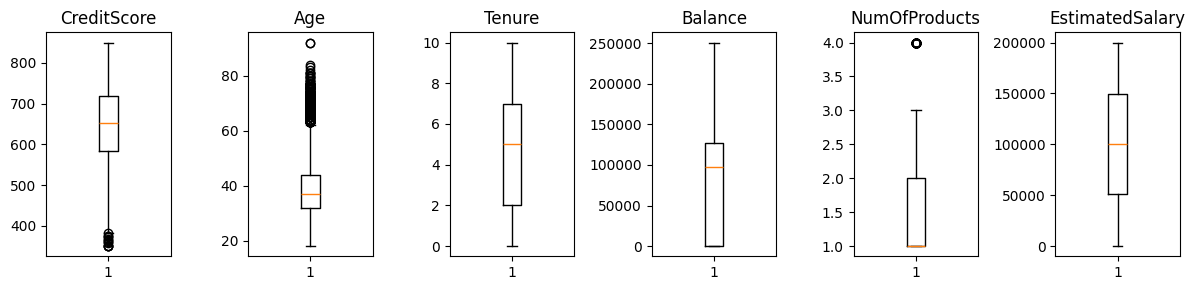

In [45]:
data = df[numerical_features].copy()

figure, axes = plt.subplots(1, 6, figsize=(12, 3))

for idx, column in enumerate(data.columns):
    series = data[column].dropna()
    axes[idx].boxplot(series)
    axes[idx].set_title(column)

plt.tight_layout()
plt.show()

**EDA Conclusions**

From this Exploratory Data Analysis we can retrieve the following information:
* We have almost no null data to treat, only 1 for age and geography
* We have class imbalance for the target variable to deal with (No churn: 7161, churn: 1840)
* Half of the bank's users are located in France. This might be an indicator that the bank's matrix is located there.
* The user base is almost equally distributed among male and female, with a slight overrepresentation of males.
* Two out of three users have a credit card
* Roughly half of users are active
* There are outliers but they might be correlated with high churn (low credit score), so we will not deal with that here


### ML Pipeline

In this section the students are required to create a ML pipeline to predict whether the customer left the bank or not.

In [ ]:
# import packages
import pandas as pd

In [82]:
# Load the dataset
path = "datasets\Churn_Modelling_train_test.csv"
df = pd.read_csv(path)

In [83]:
# Preprocess the features - create a function or a class for it (Function makes more sense here)
def transform(
    df: pd.DataFrame,
    drop_cols: list[str],
    boolean_cols: list[str],
    categorical_cols: list[str],
    drop_na: bool = True,
) -> pd.DataFrame:

    new_df = df.copy()
    
    # Drop nulls
    if drop_na:
        new_df = new_df.dropna()

    # Drop cols
    new_df = new_df.drop(columns=drop_cols)

    # Cast bools to int
    new_df[boolean_cols] = new_df[boolean_cols].astype(int)

    # One-hot encode text categoricals
    new_df = pd.get_dummies(new_df, columns=categorical_cols, drop_first=True)

    return new_df

In [84]:
# balance the dataset (if you think it is necessary)
# We won't be dealing with this as classes are not too unbalanced

In [85]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,4784,15729224,Jennings,710,France,Female,37.0,5,0.00,2,1.0,0.0,115403.31,0
1,1497,15799156,Okwuadigbo,569,Spain,Male,38.0,8,0.00,2,0.0,0.0,79618.79,0
2,1958,15674922,Beavers,710,France,Male,54.0,6,171137.62,1,1.0,1.0,167023.95,1
3,9174,15653572,Thornton,673,Spain,Male,43.0,8,127132.96,1,0.0,1.0,6009.27,1
4,9748,15775761,Iweobiegbunam,610,Germany,Female,69.0,5,86038.21,3,0.0,0.0,192743.06,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8996,5735,15596647,Henderson,768,France,Male,54.0,8,69712.74,1,1.0,1.0,69381.05,0
8997,5192,15681075,Chukwualuka,682,France,Female,58.0,1,0.00,1,1.0,1.0,706.50,0
8998,5391,15573851,Macrossan,735,France,Female,38.0,1,0.00,3,0.0,0.0,92220.12,1
8999,861,15807663,McGregor,667,France,Male,43.0,8,190227.46,1,1.0,0.0,97508.04,1


In [86]:
# Train a decision tree model using the `train sample`

df = transform(
    df=df,
    drop_cols=["RowNumber", "CustomerId", "Surname"],
    boolean_cols=["HasCrCard", "IsActiveMember"],
    categorical_cols=["Geography", "Gender"],
    drop_na=True
)

In [90]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,710,37.0,5,0.00,2,1,0,115403.31,0,False,False,False
1,569,38.0,8,0.00,2,0,0,79618.79,0,False,True,True
2,710,54.0,6,171137.62,1,1,1,167023.95,1,False,False,True
3,673,43.0,8,127132.96,1,0,1,6009.27,1,False,True,True
4,610,69.0,5,86038.21,3,0,0,192743.06,1,True,False,False


In [88]:
X = df.drop(axis=1, labels="Exited")
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [104]:
decision_tree = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [105]:
# Check the accuracy of the model on the `test sample`

decision_tree_predictions = decision_tree.predict(X_test)

# Get decision matrix
confusion_matrix(y_test, decision_tree_predictions)

array([[1399,  391],
       [ 121,  339]], dtype=int64)

In [114]:
# Get precision and recall
precision = precision_score(y_test, decision_tree_predictions)
recall = recall_score(y_test, decision_tree_predictions)
_f1_score = f1_score(y_test, decision_tree_predictions)

print(f"Precision: {precision:.2}")
print(f"Recall: {recall:.2}")
print(f"F1 Score: {_f1_score:.2}")

Precision: 0.46
Recall: 0.74
F1 Score: 0.57


### MLFlow Integration

In this section the students are required to track the model and the parameters into MLFlow.

In [116]:
# import packages for mlfow
import mlflow
from mlflow.models import infer_signature

Start a local Tracking server on port 8080 - it is necessary to import mlflow and open a new terminal

In [117]:
# Set our tracking server uri for logging on port 8080
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

Visit the MLFlow UI on `http://127.0.0.1:8080`

In [118]:
# Create a new MLflow Experiment called `Practice Experiment - {Your Name}`
mlflow.set_experiment("Practice Experiment - Mauricio Zambrano")

2026/05/24 23:09:49 INFO mlflow.tracking.fluent: Experiment with name 'Practice Experiment - Mauricio Zambrano' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1779656989411, experiment_id='2', last_update_time=1779656989411, lifecycle_stage='active', name='Practice Experiment - Mauricio Zambrano', tags={}>

In [120]:
# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(decision_tree.get_params())

    # Log the metrics
    y_pred = decision_tree.predict(X_test)
    y_proba = decision_tree.predict_proba(X_test)[:, 1]

    mlflow.log_metric("precision", precision_score(y_test, y_pred))
    mlflow.log_metric("recall", recall_score(y_test, y_pred))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred))
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba))

    # Tag the run
    mlflow.set_tag("model_type", "DecisionTreeClassifier")
    mlflow.set_tag("dataset", "Bank Churn")
    mlflow.set_tag("notes", "Baseline decision tree, no class weighting or depth limit")

    # Infer the model signature
    signature = infer_signature(X_train, decision_tree.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=decision_tree,
        artifact_path="churn_decision_tree",
        signature=signature,
        input_example=X_train.head(),
        registered_model_name="churn-decision-tree",
    )

c:\Users\mazac\Documents\EADA\Term 3\MLOps\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Successfully registered model 'churn-decision-tree'.
2026/05/24 23:12:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: churn-decision-tree, ve

🏃 View run spiffy-crab-404 at: http://127.0.0.1:8080/#/experiments/2/runs/0cce5ececf7d48c99db78d6fe885b340
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2


Created version '1' of model 'churn-decision-tree'.


### Keep practicing

In [126]:
# Create a new experiment using other models or different parameters
models = {
    "decision_tree_tuned": DecisionTreeClassifier(
        max_depth=7, min_samples_leaf=20,
        class_weight="balanced", random_state=42,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight="balanced", random_state=42, n_jobs=-1,
    ),
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=42,
        )),
    ]),
}

In [128]:
for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        # Hyperparameters
        mlflow.log_params(model.get_params())

        # Metrics
        mlflow.log_metric("precision", precision_score(y_test, y_pred))
        mlflow.log_metric("recall", recall_score(y_test, y_pred))
        mlflow.log_metric("f1_score", f1_score(y_test, y_pred))
        mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba))

        # Tags
        mlflow.set_tag("model_family", type(model).__name__)
        mlflow.set_tag("dataset", "Bank Churn")
        mlflow.set_tag("notes", f"Tuned {model_name} with class weighting")

        # Signature + model artifact
        signature = infer_signature(X_train, model.predict(X_train))
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path=model_name,
            signature=signature,
            input_example=X_train.head(),
            registered_model_name=f"churn-{model_name.replace('_', '-')}",
        )

        print(f"{model_name}: F1={f1_score(y_test, y_pred):.3f}, "
              f"AUC={roc_auc_score(y_test, y_proba):.3f}")

c:\Users\mazac\Documents\EADA\Term 3\MLOps\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Successfully registered model 'churn-decision-tree-tuned'.
2026/05/24 23:16:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: churn-decision-tr

decision_tree_tuned: F1=0.568, AUC=0.846
🏃 View run decision_tree_tuned at: http://127.0.0.1:8080/#/experiments/2/runs/4be16d90853749d99f76139e59560b87
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2


c:\Users\mazac\Documents\EADA\Term 3\MLOps\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Successfully registered model 'churn-random-forest'.
2026/05/24 23:16:43 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: churn-random-forest, ve

random_forest: F1=0.614, AUC=0.865
🏃 View run random_forest at: http://127.0.0.1:8080/#/experiments/2/runs/91c7cc0e2f514b9b801f351ed83a1c5c
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2


c:\Users\mazac\Documents\EADA\Term 3\MLOps\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Successfully registered model 'churn-logistic-regression'.
2026/05/24 23:16:47 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: churn-logistic-re

logistic_regression: F1=0.510, AUC=0.788
🏃 View run logistic_regression at: http://127.0.0.1:8080/#/experiments/2/runs/82f75da9843444fd93e7c999c866e981
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2


Created version '1' of model 'churn-logistic-regression'.
